<a href="https://colab.research.google.com/github/Ellenkyei/Classification-and-Regression/blob/main/2_000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOGISTIC REGRESSION.**

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
#loading dataset
student_records = pd.read_csv(r'StudentPerformanceFactors.csv')

In [ ]:
student_records['pass'] = (student_records['Exam_Score'] >= 70).astype(int)
student_records.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,pass
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,1


In [ ]:
#defining my variables
x = student_records.iloc[ : , [0,1,5,6,9,14]]
y = student_records.iloc[ : , -1]

**Spliting The Dataset.**

In [ ]:
#spliting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


#x_train = train_test_split(x,test_size=0.2, random_state= 42)
#x_test = train_test_split(x,test_size=0.2, random_state= 42)
#y_train = train_test_split(y,test_size=0.2, random_state= 42)
#y_test = train_test_split(y,test_size=0.2, random_state= 42)

In [ ]:
#printing the shape
#x_train.shape
#x_test.shape
#y_train.shape
#y_test.shape
#print(f'The Shape of x_train is {}')

**Training Model**

In [ ]:
lo_model = LogisticRegression()
lo_model.fit(x_train, y_train)

LogisticRegression()

**Evaluating The Model.**

For evaluating a logistic regression model (which is a classification model), several metrics can be used. Some of the most common ones include:



*   Accuracy
*   Precision
*   Recall (Sensitivity)
*   F1 Score
*   ROC Curve and AUC (Area Under the Curve)
*   Confusion Matrix






In [ ]:
y_predict = lo_model.predict(x_test)

In [ ]:
#lo_model.predict([[60,70]])


1.   **Accuracy:** The proportion of correctly classified instances.


2.   **Precision:** The proportion of positive identifications that were actually correct.








In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy:.4f}")

# Calculate Precision
precision = precision_score(y_test, y_predict)
print(f"Precision: {precision:.4f}")

Accuracy: 0.8994
Precision: 0.8457





1.   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly.
2.   **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances both.





In [ ]:
# Calculate Recall
recall = recall_score(y_test, y_predict)
print(f"Recall: {recall:.4f}")

# Calculate F1-Score
f1 = f1_score(y_test, y_predict)
print(f"F1-Score: {f1:.4f}")


Recall: 0.7557
F1-Score: 0.7982


**ROC Curve and AUC (Area Under the Curve):**

The ROC curve plots the True Positive Rate against the False Positive Rate at various threshold settings. AUC provides an aggregate measure of performance across all possible classification thresholds.




ROC AUC Score: 0.9467


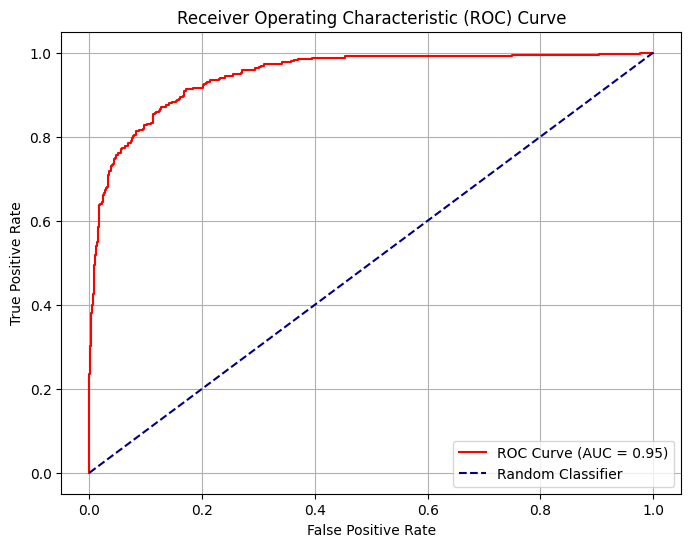

In [ ]:
# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_test, lo_model.predict_proba(x_test)[:, 1])
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lo_model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#print(thresholds)

**Confusion Matrix:**

A table that describes the performance of a classification model on a set of test data for which the true values are known. It shows the counts of true positives, true negatives, false positives, and false negatives.

In [ ]:
# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_predict)
print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[926  48]
 [ 85 263]]


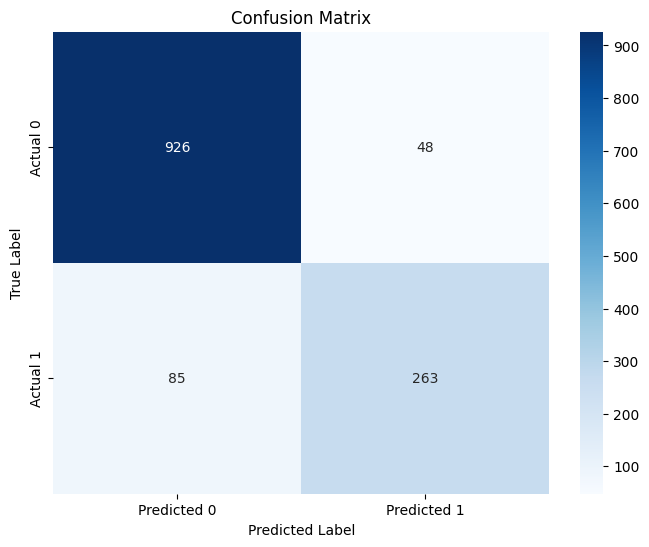

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'cm' is already calculated from the previous step
# If not, you would re-calculate it:
# cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()